---
# **Analisis Sentimen Publik terhadap Kesenjangan Implementasi Kurikulum Merdeka: Antara Visi Ideal Kementerian dan Realitas Lapangan**
---


## **Ringkasan Proyek**

Proyek ini bertujuan untuk melakukan **Analisis Sentimen** terhadap opini publik mengenai **Kurikulum Merdeka**. Fokus utama analisis ini adalah untuk mengidentifikasi adanya kesenjangan (*gap*) antara visi ideal yang dicanangkan oleh Kementerian Pendidikan, Kebudayaan, Riset, dan Teknologi dengan realitas implementasi yang dirasakan oleh para pemangku kepentingan (guru, siswa, dan orang tua) di lapangan.

### **Tahapan Utama:**
1. **Data Acquisition**: Scraping ribuan komentar dari YouTube menggunakan YouTube Data API v3.
2. **Preprocessing**: Pembersihan teks, normalisasi kata gaul (*slang*), dan ekstraksi kata dasar (*stemming*).
3. **Labeling & Augmentation**: Menggunakan kombinasi Zero-Shot Labeling (Gemini API) dan Pseudo-Labeling (SVM) untuk menangani dataset skala besar.
4. **Exploratory Data Analysis (EDA)**: Visualisasi distribusi sentimen, Word Cloud, dan analisis N-Gram untuk memahami pola kata yang sering muncul.
5. **Modeling**: Fine-tuning model **IndoBERT** (Transformer) untuk klasifikasi sentimen (Positif, Negatif, dan Netral) menggunakan teknik hybrid resampling.
6. **Evaluation**: Pengujian performa model menggunakan *Classification Report* dan *Confusion Matrix* untuk mengukur akurasi dan F1-Score.
7. **Deployment & Inference**: Export model ke format modern (ONNX & TorchScript) dan simulasi layanan API menggunakan FastAPI.


# **1. Import Library**

In [ ]:
!pip install Sastrawi wordcloud tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.7 MB/s eta 0:00:00


In [ ]:
# 1. Standard Libraries & Utilities
import re
import time
from tqdm import tqdm

# 2. Data Processing & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 3. Machine Learning (Scikit-Learn)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix

# 4. Natural Language Processing (Sastrawi & Transformers)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# 5. API & Deployment Tools
import google.generativeai as genai
from googleapiclient.discovery import build
from fastapi import FastAPI

# **2. Preparing Dataset**

## 2.1 Scraping Dataset

In [ ]:
# Konfigurasi YouTube API
API_KEY = '.....'
youtube = build('youtube', 'v3', developerKey=API_KEY)

video_ids = ['rOvhjhEbopo', '1d35WPc47Aw', 'rdm5nq9GyRM', 'McRbOUFeDpc']
semua_komentar = []

# FUNGSI SCRAPING DATA YOUTUBE
def get_youtube_comments(video_id):
    comments = []
    try:
        # Request pertama ke YouTube API
        request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=100,
            textFormat="plainText"
        )
        response = request.execute()

        while request is not None:
            for item in response['items']:
                comment = item['snippet']['topLevelComment']['snippet']['textDisplay']
                author = item['snippet']['topLevelComment']['snippet']['authorDisplayName']
                date = item['snippet']['topLevelComment']['snippet']['publishedAt']

                comments.append({
                    'Video_ID': video_id,
                    'Author': author,
                    'Date': date,
                    'Komentar': comment
                })

            # Menangani pagination untuk mengambil seluruh sisa komentar
            if 'nextPageToken' in response:
                request = youtube.commentThreads().list(
                    part="snippet",
                    videoId=video_id,
                    pageToken=response['nextPageToken'],
                    maxResults=100,
                    textFormat="plainText"
                )
                response = request.execute()
                time.sleep(0.5) # Jeda untuk menghindari limit akses API
            else:
                break
    except Exception as e:
        print(f"Terjadi kesalahan pada video {video_id}: {e}")

    return comments

# Eksekusi Scraping
for vid in video_ids:
    print(f"-> Mengambil komentar dari Video ID: {vid}")
    semua_komentar.extend(get_youtube_comments(vid))

-> Mengambil komentar dari Video ID: rOvhjhEbopo
-> Mengambil komentar dari Video ID: 1d35WPc47Aw
-> Mengambil komentar dari Video ID: rdm5nq9GyRM
-> Mengambil komentar dari Video ID: McRbOUFeDpc


## 2.2 Load Data & Eksplorasi Awal

In [ ]:
# Memuat ke DataFrame pandas
df = pd.DataFrame(semua_komentar)

print("===== Rangkuman Data =====")
# Cek Total Baris
print(f"Total Baris Awal: {len(df)}")

# Cek Data Duplikat & Langsung Menghapusnya
jumlah_duplikat = df.duplicated(subset=['Komentar']).sum()
print(f"Data Duplikat Ditemukan: {jumlah_duplikat}")
df = df.drop_duplicates(subset=['Komentar'])
print(f"Total Baris Setelah Hapus Duplikat: {len(df)}")

# Cek Missing Values
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

print()
df.head()

# Menyimpan data ke file CSV
df.to_csv('Dataset4.csv', index=False)

===== Rangkuman Data =====
Total Baris Awal: 11227
Data Duplikat Ditemukan: 137
Total Baris Setelah Hapus Duplikat: 11090

Jumlah Missing Values per Kolom:
Video_ID    0
Author      0
Date        0
Komentar    0
dtype: int64



,Video_ID,Author,Date,Komentar
0,rOvhjhEbopo,@gurugembul,2023-07-10T06:17:03Z,silahkan curhatkan keluh kesah baraya di kolom...
1,rOvhjhEbopo,@KamtoCL,2026-04-27T10:22:00Z,Yang rusak dari kurikulum merusak moral anak b...
2,rOvhjhEbopo,@KamtoCL,2026-04-27T10:15:42Z,Pendidikan sekarang tidak mutu kurikulum merde...
3,rOvhjhEbopo,@binomorgan7025,2025-12-23T04:54:04Z,Kurikulum merdeka gagal total. Bikin semua ana...
4,rOvhjhEbopo,@El-kt3oz,2025-11-21T11:51:28Z,terimakasih Bapak Mentri buat bantuan berupa s...


# **2. Text Peprocessing**

In [ ]:
df = pd.read_csv('Dataset4.csv')

# FUNGSI TEXT CLEANING
def clean_text(text):
    text = str(text).lower()                            # Case Folding
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)          # Hapus mention
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)          # Hapus hashtag
    text = re.sub(r'RT[\s]', '', text)                  # Hapus RT
    text = re.sub(r'http\S+|www\.\S+', '', text)        # Hapus URL
    text = re.sub(r'[0-9]+', '', text)                  # Hapus angka
    # Hapus emoji & karakter non-ASCII
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^\w\s]', ' ', text)                # Hapus tanda baca
    text = text.replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['Komentar_Bersih'] = df['Komentar'].apply(clean_text)

# Menghapus baris yang menjadi kosong setelah dibersihkan (misal sebelumnya hanya berisi emoji/link)
df = df[df['Komentar_Bersih'] != '']

# NORMALISASI KATA GAUL (SLANG WORDS)
slang_dict = {
    "yg": "yang", "dgn": "dengan", "tdk": "tidak", "krn": "karena",
    "bgt": "banget", "kurmer": "kurikulum merdeka", "tp": "tapi",
    "tpi": "tapi", "th": "tahun", "ttg": "tentang", "dg": "dengan",
    "gak": "tidak", "ga": "tidak", "udh": "sudah", "sy": "saya",
    "jd": "jadi", "kalo": "kalau", "utk": "untuk", "dr": "dari",
    "pndidikan": "pendidikan", "ngajar": "mengajar", "trs": "terus",
    "sbg": "sebagai", "sj": "saja", "ngga": "tidak", "sdh": "sudah",
    "pd": "pada", "sprt": "seperti", "dlm": "dalam", "bs":"bisa",
    "ttp": "tetap", "bnyk": "banyak", "msh": "masih", "skrg": "sekarang",
    "gk": "tidak", "kpd": "kepada", "jg": "juga", "hrs": "harus",
    "dpt": "dapat", "lbh": "lebih", "kl": "kalau", "bljr": "belaajar",
    "blm": "belum", "bgus": "bagus", "ad": "ada", "kyk": "seperti",
    "brp": "berapa", "knp": "kenapa", "dri": "dari", "jga": "juga",
    "thn": "tahun", "g": "tidak", "tsb": "tersebut", "bkn": "bukan",
    "bgs": "bagus", "gurgem": "guru gembul", "trus": "terus",
    "kurmer": "kurikulum merdeka", "kumer": "kurikulum merdeka",
    "kepsek": "kepala sekolah", "pmm": "platform merdeka mengajar",
    "kalo": "kalau", "klo": "kalau", "gk": "tidak", "tp": "tapi",
    "gmn": "bagaimana", "ribet": "rumit", "org": "orang", "jgn": "jangan",
    "gt": "gitu", "kt": "kata", "aj": "aja", "gw": "saya"
}

def normalize_slang(text):
    words = text.split()
    normalized_words = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

# Proses normalisasi slangw words
df['Komentar_Bersih'] = df['Komentar_Bersih'].apply(normalize_slang)

# Menampilkan perbandingan 5 data teratas sebelum dan sesudah dibersihkan
print("Perbandingan Hasil Preprocessing:")
display(df[['Komentar', 'Komentar_Bersih']].head())

# Menyimpan data bersih ke file CSV
df.to_csv('Clean_Dataset4.csv', index=False)

Perbandingan Hasil Preprocessing:


,Komentar,Komentar_Bersih
0,silahkan curhatkan keluh kesah baraya di kolom...,silahkan curhatkan keluh kesah baraya di kolom...
1,Yang rusak dari kurikulum merusak moral anak b...,yang rusak dari kurikulum merusak moral anak b...
2,Pendidikan sekarang tidak mutu kurikulum merde...,pendidikan sekarang tidak mutu kurikulum merde...
3,Kurikulum merdeka gagal total. Bikin semua ana...,kurikulum merdeka gagal total bikin semua anak...
4,terimakasih Bapak Mentri buat bantuan berupa s...,terimakasih bapak mentri buat bantuan berupa s...


# **3. Data Labelling**

## 3.1 API Gemini Labeling

In [ ]:
# Konfigurasi API
GOOGLE_API_KEY = "....."
genai.configure(api_key=GOOGLE_API_KEY)

# Melihat daftar model yang tersedia
print(f"Available models: {[m.name for m in genai.list_models()]}")

Available models: ['models/gemini-2.5-flash', 'models/gemini-2.5-pro', 'models/gemini-2.0-flash', 'models/gemini-2.0-flash-001', 'models/gemini-2.0-flash-lite-001', 'models/gemini-2.0-flash-lite', 'models/gemini-2.5-flash-preview-tts', 'models/gemini-2.5-pro-preview-tts', 'models/gemma-4-26b-a4b-it', 'models/gemma-4-31b-it', 'models/gemini-flash-latest', 'models/gemini-flash-lite-latest', 'models/gemini-pro-latest', 'models/gemini-2.5-flash-lite', 'models/gemini-2.5-flash-image', 'models/gemini-3-pro-preview', 'models/gemini-3-flash-preview', 'models/gemini-3.1-pro-preview', 'models/gemini-3.1-pro-preview-customtools', 'models/gemini-3.1-flash-lite-preview', 'models/gemini-3.1-flash-lite', 'models/gemini-3-pro-image-preview', 'models/gemini-3-pro-image', 'models/nano-banana-pro-preview', 'models/gemini-3.1-flash-image-preview', 'models/gemini-3.1-flash-image', 'models/gemini-3.5-flash', 'models/lyria-3-clip-preview', 'models/lyria-3-pro-preview', 'models/gemini-3.1-flash-tts-preview', 

In [ ]:
# Memilih model Gemini API
model = genai.GenerativeModel('gemini-3.5-flash')

# Muat Data Bersih
df = pd.read_csv('Clean_Dataset4.csv')
komentar_list = df['Komentar_Bersih'].tolist()

# Siapkan list kosong untuk menampung hasil
hasil_sentimen = []

# Fungsi untuk mengirim instruksi ke Gemini API
def label_sentimen_batch(batch_komentar):
    # Menyusun prompt instruksi pelabelan untuk konteks Kurikulum Merdeka
    prompt = f"""
    Kamu adalah ahli Analisis Sentimen.
    Tugasmu adalah menganalisis sentimen dari daftar komentar YouTube terkait "Implementasi Kurikulum Merdeka".
    Fokus pada kesenjangan antara visi ideal kementerian dan realitas lapangan.

    Berikan label sentimen yang sesuai (HANYA pilih salah satu: Positif, Negatif, atau Netral) untuk setiap komentar.
    Positif: Mendukung, mengapresiasi, atau melihat sisi baik Kurikulum Merdeka.
    Negatif: Mengeluh, merasa terbebani (administrasi/disorientasi), menolak, atau mengkritik Kurikulum Merdeka.
    Netral: Hanya bertanya, berkomentar di luar konteks, atau tidak menunjukkan emosi yang jelas.

    Berikut adalah daftar komentarnya:
    {batch_komentar}

    Balas dengan format persis seperti ini (hanya labelnya saja, pisahkan dengan koma, urutannya harus sama persis dengan input):
    Label1, Label2, Label3, ...
    """

    try:
        response = model.generate_content(prompt)
        # Membersihkan output dan memecahnya menjadi list
        labels = [label.strip() for label in response.text.split(',')]
        return labels
    except Exception as e:
        print(f"Terjadi error pada API: {e}")
        return ["Error"] * len(batch_komentar)

# Sistem Looping (Perulangan) dengan Batch
ukuran_batch = 50 # Sesuai kapasitas optimal API
total_data = len(komentar_list)

print(f"Memulai pelabelan {total_data} data dengan batch size {ukuran_batch}...")

for i in tqdm(range(0, total_data, ukuran_batch)):
    # Mengambil 50 data per putaran
    batch = komentar_list[i:i + ukuran_batch]

    # Format batch agar mudah dibaca AI (misal: "1. Komentar A \n 2. Komentar B")
    teks_batch = "\n".join([f"{idx+1}. {teks}" for idx, teks in enumerate(batch)])

    # Panggil API
    labels = label_sentimen_batch(teks_batch)

    # Pastikan jumlah label sama dengan jumlah komentar di batch untuk menghindari error
    if len(labels) == len(batch):
        hasil_sentimen.extend(labels)
    else:
        # Fallback jika format AI meleset
        hasil_sentimen.extend(["Netral"] * len(batch))

    # Jeda 3 detik agar tidak terkena limitasi (Rate Limit) dari server Google
    time.sleep(3)

# 5. Menyimpan Hasil ke CSV Baru
df['Sentimen_AI'] = hasil_sentimen[:len(df)] # Memastikan panjang baris sama
df.to_csv('labeled_dataset4.csv', index=False)

Memulai pelabelan 5417 data dengan batch size 50...


 18%|█▊        | 20/109 [02:05<08:30,  5.74s/it]WARNING:tornado.access:429 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 354.57ms


Terjadi error pada API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite
Please retry in 12.449987863s.


 21%|██        | 23/109 [02:20<07:32,  5.27s/it]WARNING:tornado.access:429 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 608.13ms


Terjadi error pada API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite
Please retry in 57.850169379s.


...

Terjadi error pada API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite
Please retry in 16.590676063s.


 99%|█████████▉| 108/109 [07:05<00:03,  3.33s/it]WARNING:tornado.access:429 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 254.67ms


Terjadi error pada API: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite
Please retry in 13.277555503s.


100%|██████████| 109/109 [07:08<00:00,  3.93s/it]


Pelabelan selesai! File '5453_labeled_dataset.csv' berhasil disimpan.


### Distribution of API Labeled Data

In [ ]:
# Load the labeled dataset
df_labeled = pd.read_csv('labeled_dataset4.csv')

print("===== Dataset Information =====")
df_labeled.info()

print("\n===== Distribution of Sentimen_AI =====")
sentiment_distribution = df_labeled['Sentimen_AI'].value_counts()
display(sentiment_distribution)

print()
display(df_labeled.head())

===== Dataset Information =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11090 entries, 0 to 11089
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Video_ID         11090 non-null  object
 1   Author           11090 non-null  object
 2   Date             11090 non-null  object
 3   Komentar         11090 non-null  object
 4   Komentar_Bersih  11090 non-null  object
 5   Sentimen_AI      1150 non-null   object
dtypes: object(6)
memory usage: 520.0+ KB

===== Distribution of Sentimen_AI =====


,count
Sentimen_AI,
Netral,551
Negatif,494
Positif,105


,Video_ID,Author,Date,Komentar,Komentar_Bersih,Sentimen_AI
0,rOvhjhEbopo,@gurugembul,2023-07-10T06:17:03Z,silahkan curhatkan keluh kesah baraya di kolom...,silahkan curhatkan keluh kesah baraya di kolom...,Netral
1,rOvhjhEbopo,@KamtoCL,2026-04-27T10:22:00Z,Yang rusak dari kurikulum merusak moral anak b...,yang rusak dari kurikulum merusak moral anak b...,Negatif
2,rOvhjhEbopo,@KamtoCL,2026-04-27T10:15:42Z,Pendidikan sekarang tidak mutu kurikulum merde...,pendidikan sekarang tidak mutu kurikulum merde...,Negatif
3,rOvhjhEbopo,@binomorgan7025,2025-12-23T04:54:04Z,Kurikulum merdeka gagal total. Bikin semua ana...,kurikulum merdeka gagal total bikin semua anak...,Negatif
4,rOvhjhEbopo,@El-kt3oz,2025-11-21T11:51:28Z,terimakasih Bapak Mentri buat bantuan berupa s...,terimakasih bapak mentri buat bantuan berupa s...,Netral


/tmp/ipykernel_3610/807095181.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')


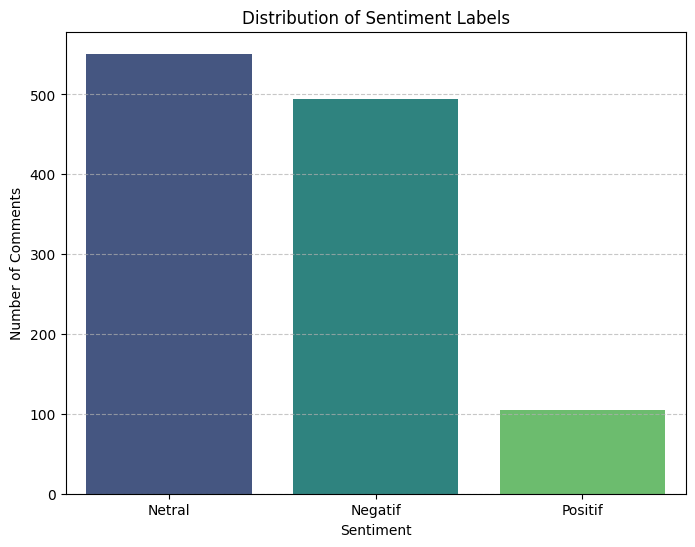

In [ ]:
# Visualize the distribution of 'Sentimen_AI'
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 3.2 Pseudo-Labeling

In [ ]:
# 1. Memuat Data
# Ganti 'Data_Komentar_API.csv' dengan nama file yang berisi seluruh data (termasuk 1150 yang sudah berlabel)
# Pastikan ada kolom 'Komentar_Bersih' dan kolom 'Sentimen' (di mana sisanya berisi NaN/kosong)
df = pd.read_csv('labeled_dataset4.csv')

# Memisahkan data yang sudah memiliki label dan yang masih kosong
df_labeled = df.dropna(subset=['Sentimen_AI']).copy()
df_unlabeled = df[df['Sentimen_AI'].isna()].copy()

print(f"Jumlah data latih (Terlabeli AI): {len(df_labeled)} baris")
print(f"Jumlah data yang akan diprediksi (Pseudo-Labeling): {len(df_unlabeled)} baris")

# 2. Membangun Pipeline Model Support Vector Machine (SVM)
# TF-IDF bertugas merubah teks menjadi representasi angka
# LinearSVC adalah model klasifikasi yang cepat dan akurat untuk teks
model_pseudo = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('svm', LinearSVC(class_weight='balanced', random_state=42))
])

# 3. Melatih Model dengan 1.150 Data
model_pseudo.fit(df_labeled['Komentar_Bersih'], df_labeled['Sentimen_AI'])
print("Model berhasil dilatih!")

# 4. Melakukan Pseudo-Labeling pada Sisa Data
prediksi_sentimen = model_pseudo.predict(df_unlabeled['Komentar_Bersih'])
df_unlabeled['Sentimen_AI'] = prediksi_sentimen

# 5. Menggabungkan Kembali Seluruh Data
df_final = pd.concat([df_labeled, df_unlabeled], ignore_index=True)

# 6. Menyimpan Hasil Akhir
df_final.to_csv('labeled_dataset4_full.csv', index=False)

Jumlah data latih (Terlabeli AI): 1150 baris
Jumlah data yang akan diprediksi (Pseudo-Labeling): 9940 baris
Model berhasil dilatih!


### Distribution of Pseudo-Labeling Data

In [ ]:
# Load the labeled dataset
df_labeled = pd.read_csv('labeled_dataset4_full.csv')

print("\n===== Dataset Information =====")
df_labeled.info()

print()
display(df_labeled.iloc[1151:1156])


===== Dataset Information =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11090 entries, 0 to 11089
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Video_ID         11090 non-null  object
 1   Author           11090 non-null  object
 2   Date             11090 non-null  object
 3   Komentar         11090 non-null  object
 4   Komentar_Bersih  11090 non-null  object
 5   Sentimen_AI      11090 non-null  object
dtypes: object(6)
memory usage: 520.0+ KB



,Video_ID,Author,Date,Komentar,Komentar_Bersih,Sentimen_AI
1151,rOvhjhEbopo,@dallyzain,2023-07-12T02:27:05Z,"Kenapa yang exkul ga dijadiin santapaan utama,...",kenapa yang exkul tidak dijadiin santapaan uta...,Negatif
1152,rOvhjhEbopo,@AyunkBaretto,2023-07-12T02:27:04Z,Birokrasi pendidikan di indonesia itu sangat k...,birokrasi pendidikan di indonesia itu sangat k...,Negatif
1153,rOvhjhEbopo,@cariyuli,2023-07-12T02:21:42Z,skill guru kita itu rata2 kebanyakan masih men...,skill guru kita itu rata kebanyakan masih meng...,Netral
1154,rOvhjhEbopo,@marulich6337,2023-07-12T02:19:49Z,"Pak guru, *Sekedar Harapan* untuk kurikulum me...",pak guru sekedar harapan untuk kurikulum merde...,Netral
1155,rOvhjhEbopo,@muhammadadelkomar5808,2023-07-12T02:19:10Z,"""Semanis apapun"" kalau biaya pengadaan,kesejah...",semanis apapun kalau biaya pengadaan kesejahte...,Negatif


# **4. Exploratory Data Analyst**

## 4.1 Data Preparation for EDA

In [ ]:
df = pd.read_csv('labeled_dataset4_full.csv')
# Mengaktifkan progress bar untuk pandas
tqdm.pandas()

# Menginisialisasi modul NLP Sastrawi
stemmer = StemmerFactory().create_stemmer()
stopword = StopWordRemoverFactory().create_stop_word_remover()

# Mengamankan kolom teks utuh untuk IndoBERT
df.rename(columns={'Komentar_Bersih': 'Komentar_Model'}, inplace=True)

# Fungsi untuk menghapus stopwords dan stemming
def prep_eda(text):
    text = str(text)
    text = stopword.remove(text) # Hapus kata hubung
    text = stemmer.stem(text)    # Ubah ke kata dasar
    return text

# Membuat kolom baru khusus untuk visualisasi
df['Komentar_EDA'] = df['Komentar_Model'].progress_apply(prep_eda)

# Menyimpan dataset yang sudah disteamming
df.to_csv('stemming_dataset4.csv', index=False)

100%|██████████| 11090/11090 [29:19<00:00,  6.30it/s]


In [ ]:
df = pd.read_csv('stemming_dataset4.csv')
df.head()

,Video_ID,Author,Date,Komentar,Komentar_Model,Sentimen_AI,Komentar_EDA
0,rOvhjhEbopo,@gurugembul,2023-07-10T06:17:03Z,silahkan curhatkan keluh kesah baraya di kolom...,silahkan curhatkan keluh kesah baraya di kolom...,Netral,silah curhatkan keluh kesah baraya kolom komen...
1,rOvhjhEbopo,@KamtoCL,2026-04-27T10:22:00Z,Yang rusak dari kurikulum merusak moral anak b...,yang rusak dari kurikulum merusak moral anak b...,Negatif,rusak kurikulum rusak moral anak bangsa anak i...
2,rOvhjhEbopo,@KamtoCL,2026-04-27T10:15:42Z,Pendidikan sekarang tidak mutu kurikulum merde...,pendidikan sekarang tidak mutu kurikulum merde...,Negatif,didik sekarang mutu kurikulum merdeka kurikulu...
3,rOvhjhEbopo,@binomorgan7025,2025-12-23T04:54:04Z,Kurikulum merdeka gagal total. Bikin semua ana...,kurikulum merdeka gagal total bikin semua anak...,Negatif,kurikulum merdeka gagal total bikin semua anak...
4,rOvhjhEbopo,@El-kt3oz,2025-11-21T11:51:28Z,terimakasih Bapak Mentri buat bantuan berupa s...,terimakasih bapak mentri buat bantuan berupa s...,Netral,terimakasih bapak tri buat bantu upa smart tv nya


## 4.2 Distribusi Label Sentimen


--- Distribution of Sentimen_AI ---


,count
Sentimen_AI,
Netral,5574
Negatif,4971
Positif,545


/tmp/ipykernel_1231/3236655364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')


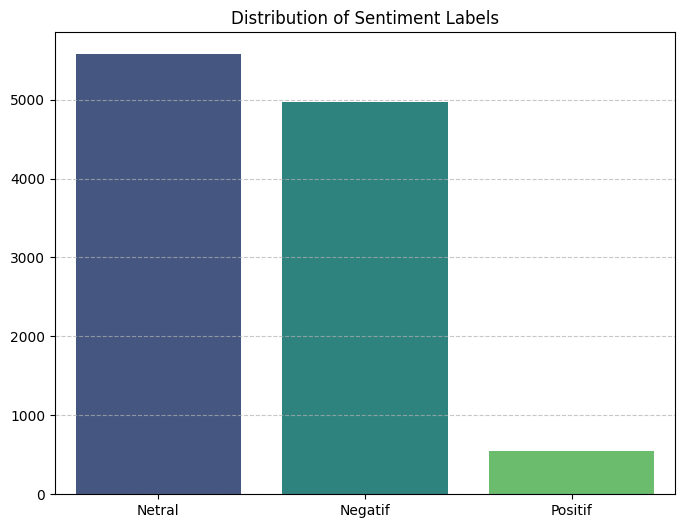

In [ ]:
print("\n--- Distribution of Sentimen_AI ---")
sentiment_distribution = df_labeled['Sentimen_AI'].value_counts()
display(sentiment_distribution)

# Visualize the distribution of 'Sentimen_AI'
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

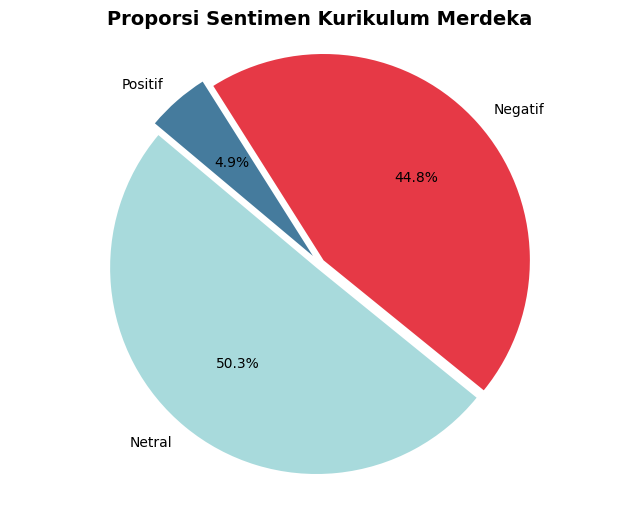

In [ ]:
plt.figure(figsize=(8, 6))
sns.set_palette("pastel")
df = pd.read_csv('stemming_dataset4.csv')

# Menghitung jumlah masing-masing sentimen
sentimen_counts = df['Sentimen_AI'].value_counts()

# Membuat Pie Chart
plt.pie(sentimen_counts, labels=sentimen_counts.index, autopct='%1.1f%%',
        startangle=140, explode=(0.025, 0.025, 0.05), shadow=False,
        colors=['#a8dadc', '#e63946', '#457b9d'])
plt.title('Proporsi Sentimen Kurikulum Merdeka', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

## **4.3 Distribusi Panjang Teks**

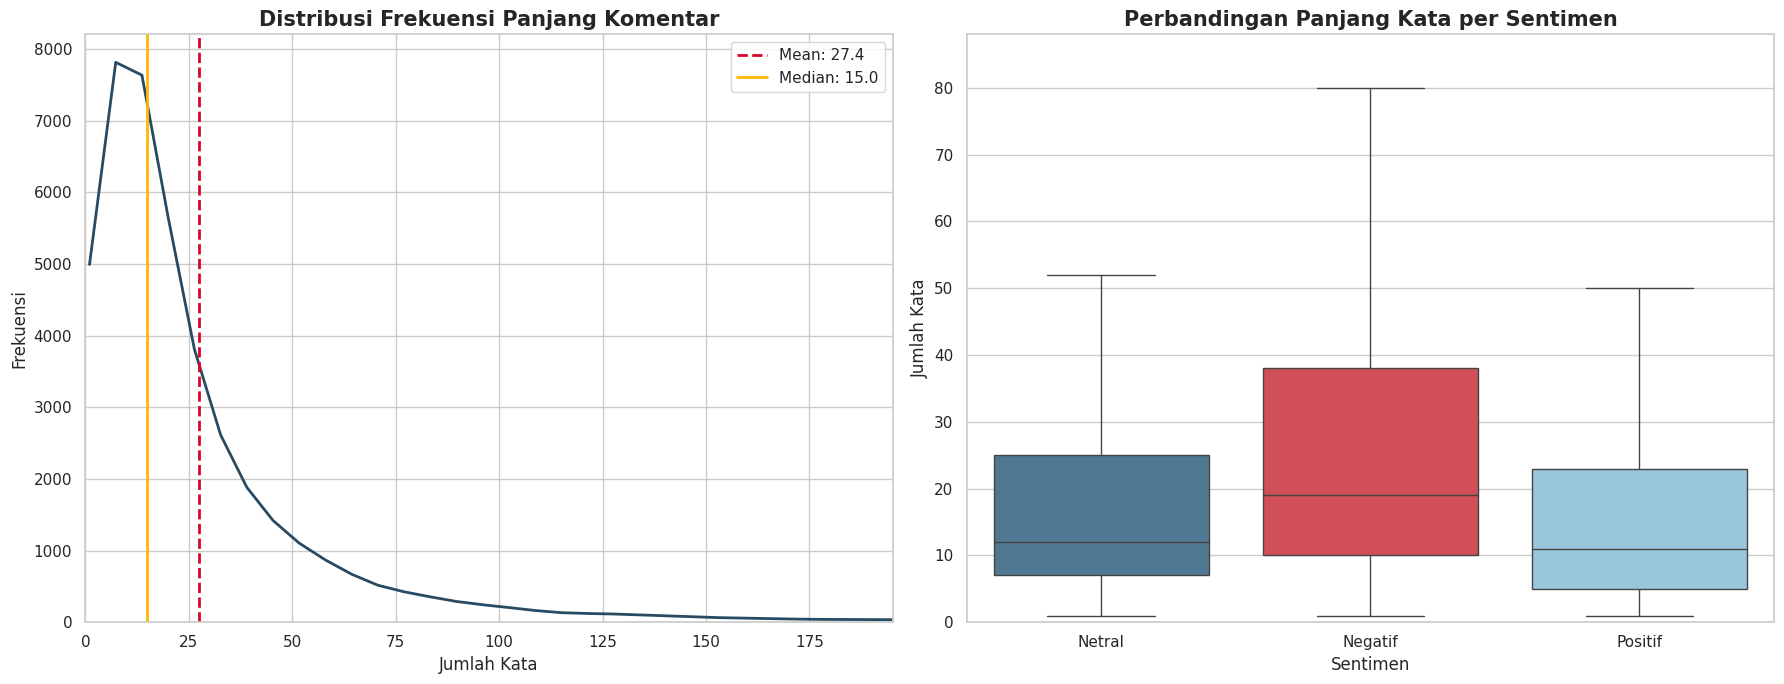

In [ ]:
df = pd.read_csv('stemming_dataset4.csv')

# Set tema visualisasi
sns.set_theme(style="whitegrid")

# Menghitung jumlah kata
df['Jumlah_Kata'] = df['Komentar_Model'].astype(str).apply(lambda x: len(x.split()))

# Hitung statistik untuk anotasi
mean_val = df['Jumlah_Kata'].mean()
median_val = df['Jumlah_Kata'].median()

# Membuat figure dengan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ========== 1. Distribusi Keseluruhan dengan Nilai Frekuensi Riil ==========
# stat='count' memastikan sumbu Y menunjukkan jumlah baris/data
sns.histplot(data=df, x='Jumlah_Kata', bins=50, kde=True, stat="count",
             fill=True, color='#284b63', alpha=0.3, ax=axes[0],
             edgecolor=None, line_kws={'linewidth': 2})

# Menghilangkan elemen batang (patches) agar hanya kurva dan area fill yang terlihat
for patch in axes[0].patches:
    patch.set_visible(False)

axes[0].axvline(mean_val, color='#d90429', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
axes[0].axvline(median_val, color='#ffb703', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}')
axes[0].set_title('Distribusi Frekuensi Panjang Komentar', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].set_xlim(0, df['Jumlah_Kata'].quantile(0.99))
axes[0].legend()

# ========== 2. Boxplot Sentimen ==========
palette_sentimen = {'Negatif': '#e63946', 'Netral': '#457b9d', 'Positif': '#8ecae6'}
sns.boxplot(data=df, x='Sentimen_AI', y='Jumlah_Kata', palette=palette_sentimen,
            hue='Sentimen_AI', legend=False, showfliers=False, ax=axes[1])
axes[1].set_title('Perbandingan Panjang Kata per Sentimen', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('Jumlah Kata')
axes[1].set_ylim(0, df['Jumlah_Kata'].quantile(0.95))

plt.tight_layout()
plt.show()

## 4.4 Word Cloud Per-Serntimen

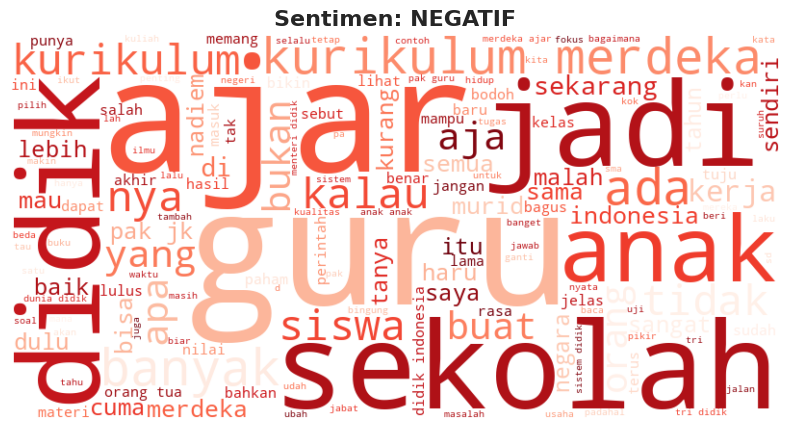

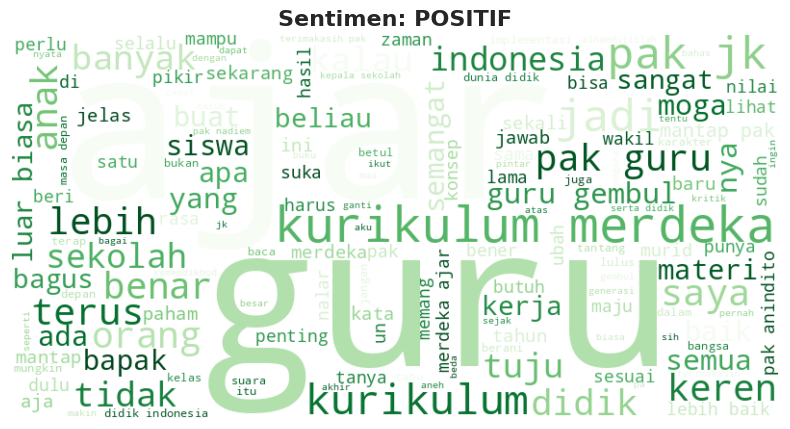

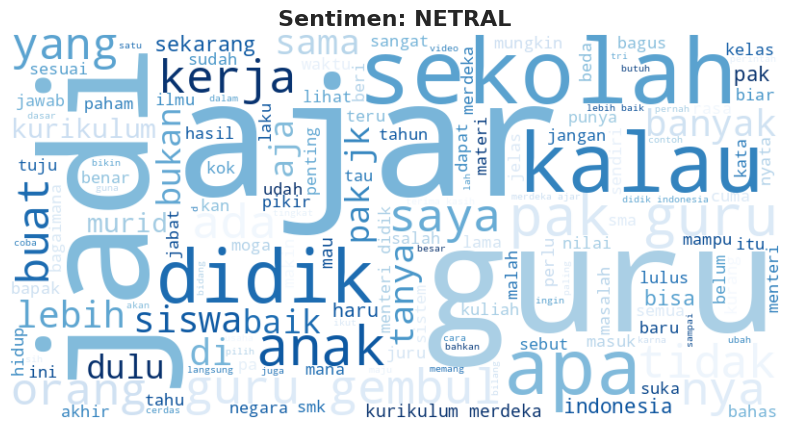

In [ ]:
def generate_wordcloud(sentiment_label, color_map):
    # Memastikan kolom Komentar_EDA diubah menjadi string dan difilter berdasarkan sentimen
    filtered_df = df[df['Sentimen_AI'] == sentiment_label]['Komentar_EDA'].astype(str)

    # Menggabungkan seluruh teks
    text_data = " ".join(review for review in filtered_df)

    # Konfigurasi Word Cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          colormap=color_map, max_words=150).generate(text_data)

    # Menampilkan gambar
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Sentimen: {sentiment_label.upper()}', fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()

# Memanggil fungsi untuk masing-masing sentimen
generate_wordcloud('Negatif', 'Reds')
generate_wordcloud('Positif', 'Greens')
generate_wordcloud('Netral', 'Blues')

## **4.5 Visualisasi Top 20 N-Gram**

/tmp/ipykernel_2253/3203603452.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_unigram, x='Frekuensi', y='Teks', ax=axes[0], palette='viridis')
/tmp/ipykernel_2253/3203603452.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bigram, x='Frekuensi', y='Teks', ax=axes[1], palette='magma')
/tmp/ipykernel_2253/3203603452.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_trigram, x='Frekuensi', y='Teks', ax=axes[2], palette='cubehelix')


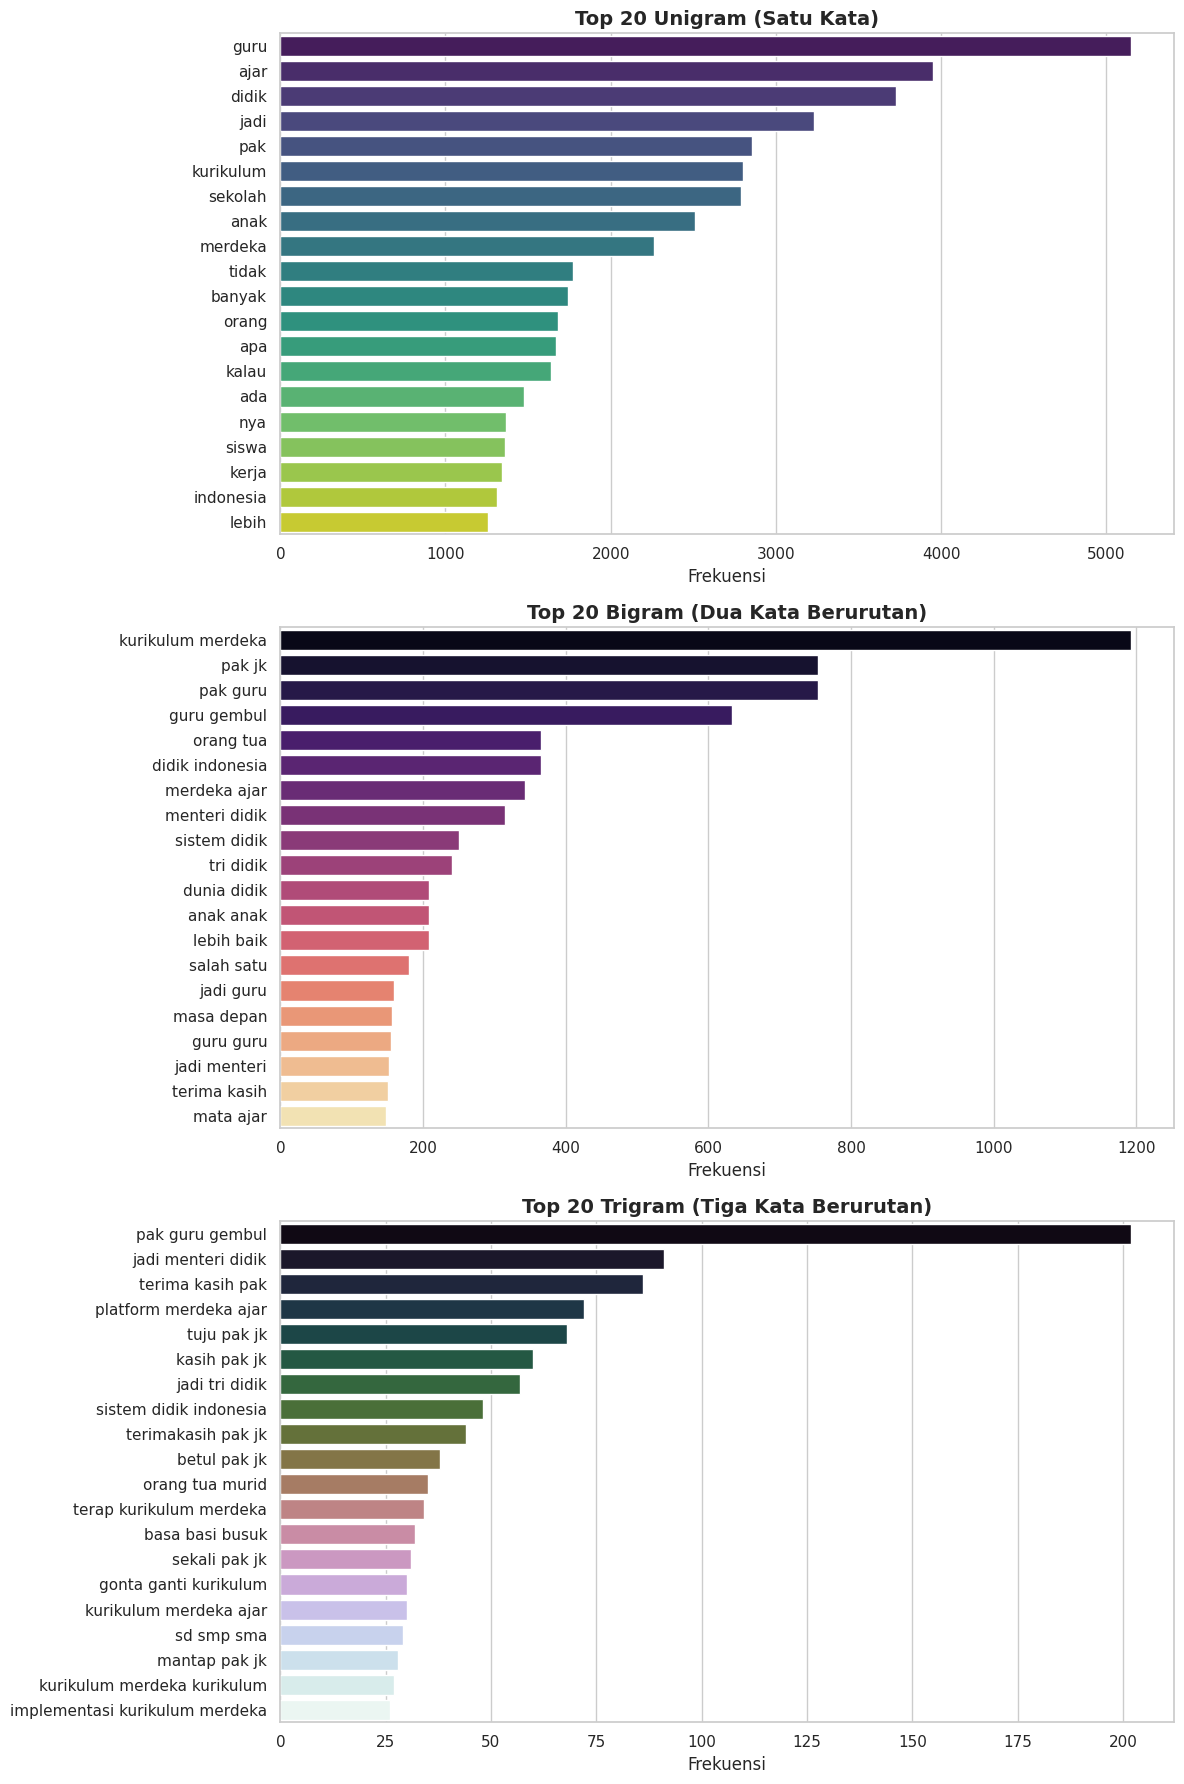

In [ ]:
# Fungsi untuk mengekstrak Top N-Grams
def get_top_ngrams(corpus, n_top=20, ngram_range=(1,1)):
    # Mengabaikan nilai kosong
    corpus = corpus.dropna().astype(str)
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    df_ngram = pd.DataFrame(words_freq[:n_top], columns=['Teks', 'Frekuensi'])
    return df_ngram

# Ingat: Kita menggunakan Komentar_EDA yang sudah bebas stopwords dan distemming
teks_corpus = df['Komentar_EDA']

# Ekstraksi
top_unigram = get_top_ngrams(teks_corpus, 20, (1, 1))
top_bigram = get_top_ngrams(teks_corpus, 20, (2, 2))
top_trigram = get_top_ngrams(teks_corpus, 20, (3, 3))

# Plotting N-Grams
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot Unigram
sns.barplot(data=top_unigram, x='Frekuensi', y='Teks', ax=axes[0], palette='viridis')
axes[0].set_title('Top 20 Unigram (Satu Kata)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

# Plot Bigram
sns.barplot(data=top_bigram, x='Frekuensi', y='Teks', ax=axes[1], palette='magma')
axes[1].set_title('Top 20 Bigram (Dua Kata Berurutan)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

# Plot Trigram
sns.barplot(data=top_trigram, x='Frekuensi', y='Teks', ax=axes[2], palette='cubehelix')
axes[2].set_title('Top 20 Trigram (Tiga Kata Berurutan)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
# Memuat ulang dataset
df = pd.read_csv('stemming_dataset4.csv')

**Fungsi untuk mefilter komentar berdasarkan keyword**

In [1]:
def cari_komentar(keyword, n_head=10, nama_file=None):
    # Memfilter dataset berdasarkan frasa pada kolom Komentar_EDA
    hasil_filter = df[df['Komentar_EDA'].str.contains(keyword, case=False, na=False)]

    print(f"===== Hasil Pencarian: '{keyword}' =====")
    print(f"Ditemukan {len(hasil_filter)} baris.\n")

    # Menampilkan hasil di notebook
    display(hasil_filter[['Komentar', 'Sentimen_AI']].head(n_head))

    # Menyimpan ke Excel
    if nama_file:
        # Menambahkan ekstensi .xlsx jika belum ada
        if not nama_file.endswith('.xlsx'):
            nama_file += '.xlsx'
        hasil_filter.to_excel(nama_file, index=False)

    return hasil_filter

### **4.5.1 Filter Komentar: Unigram**
Menampilkan komentar yang mengandung topik spesifik berdasarkan 1 keyword
- guru
- kurikulum
- sekolah
- anak
- merdeka
- siswa
- kerja
- indonesia

In [ ]:
filter_data = cari_komentar('guru', nama_file='guru')

===== Hasil Pencarian: 'guru' =====
Ditemukan 3033 baris.



,Komentar,Sentimen_AI
6,"Saat membuat soal ulangan, kenapa masih banyak...",Negatif
11,GURUNYA SAJA YANG MERDEKA.....MURID SAMA ORANG...,Negatif
16,Bro guru... saya mengkhayal sekolah tanpa bata...,Netral
17,Selama Indonedia belum punya internet sendiri ...,Negatif
18,Terlalu sulit untuk dilaksanakan oleh guru mau...,Negatif
19,bnyak cerita2 sedih guru2 yg mengajar di seko...,Negatif
21,Bener kkm buat guru bnyak ngatur nilai. Terus ...,Negatif
29,Kurikulum merdeka bgus tp ad kendala jk dtrapk...,Netral
33,pak guru gembul sangat layak menjadi menteri p...,Netral
34,kembalikan guru menjdi vertikal di bawahi keme...,Netral


In [ ]:
filter_data = cari_komentar('kurikulum', nama_file='kurikulum')

===== Hasil Pencarian: 'kurikulum' =====
Ditemukan 1973 baris.



,Komentar,Sentimen_AI
1,Yang rusak dari kurikulum merusak moral anak b...,Negatif
2,Pendidikan sekarang tidak mutu kurikulum merde...,Negatif
3,Kurikulum merdeka gagal total. Bikin semua ana...,Negatif
10,ganti itu kurikulum LGBT,Negatif
12,"Mohon dimasukkan kembali dalam kurikulum, mate...",Negatif
17,Selama Indonedia belum punya internet sendiri ...,Negatif
20,Seharusnya pengawas sekolah harus paham kuriku...,Negatif
22,"Gagasan Kurikulum merdeka itu bagus, tapi impl...",Netral
23,Kurikulum merdeka menjadi kurikulum pembodohan,Negatif
25,Kurmer dan CGP adalah program Pembodohan dan P...,Negatif


In [ ]:
filter_data = cari_komentar('sekolah', nama_file='sekolah')

===== Hasil Pencarian: 'sekolah' =====
Ditemukan 1674 baris.



,Komentar,Sentimen_AI
7,"Siswa saya di kelas 4, ada yang sama sekali be...",Netral
9,Pak hrs nyaseragamkn semua sekolah itu sama,Netral
16,Bro guru... saya mengkhayal sekolah tanpa bata...,Netral
17,Selama Indonedia belum punya internet sendiri ...,Negatif
18,Terlalu sulit untuk dilaksanakan oleh guru mau...,Negatif
19,bnyak cerita2 sedih guru2 yg mengajar di seko...,Negatif
20,Seharusnya pengawas sekolah harus paham kuriku...,Negatif
21,Bener kkm buat guru bnyak ngatur nilai. Terus ...,Negatif
26,Anak sekarang gak pernah baca kesusatraan. Pad...,Negatif
27,Sekolah masih gagap untuk implementasi ini. Mi...,Negatif


In [ ]:
filter_data = cari_komentar('anak', nama_file='anak')

===== Hasil Pencarian: 'anak' =====
Ditemukan 1513 baris.



,Komentar,Sentimen_AI
1,Yang rusak dari kurikulum merusak moral anak b...,Negatif
3,Kurikulum merdeka gagal total. Bikin semua ana...,Negatif
5,Pengetahuan dasar setiap anak Indonesia adalah...,Netral
7,"Siswa saya di kelas 4, ada yang sama sekali be...",Netral
11,GURUNYA SAJA YANG MERDEKA.....MURID SAMA ORANG...,Negatif
12,"Mohon dimasukkan kembali dalam kurikulum, mate...",Negatif
17,Selama Indonedia belum punya internet sendiri ...,Negatif
26,Anak sekarang gak pernah baca kesusatraan. Pad...,Negatif
27,Sekolah masih gagap untuk implementasi ini. Mi...,Negatif
39,"Pak guru, mohon pencerahan 🙏 :\nUtk sekolah sw...",Netral


In [ ]:
filter_data = cari_komentar('merdeka', nama_file='merdeka')

===== Hasil Pencarian: 'merdeka' =====
Ditemukan 1648 baris.



,Komentar,Sentimen_AI
2,Pendidikan sekarang tidak mutu kurikulum merde...,Negatif
3,Kurikulum merdeka gagal total. Bikin semua ana...,Negatif
11,GURUNYA SAJA YANG MERDEKA.....MURID SAMA ORANG...,Negatif
12,"Mohon dimasukkan kembali dalam kurikulum, mate...",Negatif
20,Seharusnya pengawas sekolah harus paham kuriku...,Negatif
22,"Gagasan Kurikulum merdeka itu bagus, tapi impl...",Netral
23,Kurikulum merdeka menjadi kurikulum pembodohan,Negatif
25,Kurmer dan CGP adalah program Pembodohan dan P...,Negatif
27,Sekolah masih gagap untuk implementasi ini. Mi...,Negatif
29,Kurikulum merdeka bgus tp ad kendala jk dtrapk...,Netral


In [ ]:
filter_data = cari_komentar('siswa', nama_file='siswa')

===== Hasil Pencarian: 'siswa' =====
Ditemukan 938 baris.



,Komentar,Sentimen_AI
7,"Siswa saya di kelas 4, ada yang sama sekali be...",Netral
24,Kurner menyebabkan siswa-siswi makin nglonjak....,Negatif
29,Kurikulum merdeka bgus tp ad kendala jk dtrapk...,Netral
30,Apakah sudah ada penelitian bhw penilaian yg d...,Negatif
55,Sistem zona sebenarnya bagus.cm penerapan zona...,Netral
56,Enggak usah ngeluh kalau siswanya tak bisa ber...,Negatif
57,Untuk sma tujuan utama masuk PTN untuk SNBP se...,Negatif
64,Mas menteriNadim tu ngak cucok blas. carut mar...,Negatif
83,"Ini loh bagus, tapi kenapa dalam penerapannya ...",Netral
88,Guru honorer di sekolah milik pemerintah adala...,Negatif


In [ ]:
filter_data = cari_komentar('kerja', nama_file='kerja')

===== Hasil Pencarian: 'kerja' =====
Ditemukan 903 baris.



,Komentar,Sentimen_AI
11,GURUNYA SAJA YANG MERDEKA.....MURID SAMA ORANG...,Negatif
17,Selama Indonedia belum punya internet sendiri ...,Negatif
29,Kurikulum merdeka bgus tp ad kendala jk dtrapk...,Netral
46,"Dari Pusat sebenarnya bagus lho, tapi ketika d...",Netral
70,"Saya sangat suka baca buku, dengan membaca buk...",Netral
112,kang @gurugembul mampir atuh kang ketempat sim...,Netral
114,Diskusi² tentang pendidikan kita kaya akan teo...,Negatif
118,Sebenarnya pak tidak ada yg tidak bagus mengen...,Netral
124,Tuntutan supervisi adalah administrasi guru pr...,Negatif
132,Saya guru SMA asal flores NTT satu hal ...,Netral


In [ ]:
filter_data = cari_komentar('indonesia', nama_file='indonesia')

===== Hasil Pencarian: 'indonesia' =====
Ditemukan 1073 baris.



,Komentar,Sentimen_AI
3,Kurikulum merdeka gagal total. Bikin semua ana...,Negatif
5,Pengetahuan dasar setiap anak Indonesia adalah...,Netral
17,Selama Indonedia belum punya internet sendiri ...,Negatif
38,Yg membuat pendidikan di indonesia semakin sem...,Negatif
47,Justru diterapkan kurikulum merdeka etika pese...,Negatif
51,Indonesia tdk pendidikan jd maklum 😂,Negatif
75,Sudah saatnya bangsa Indonesia kembali ke JATI...,Netral
80,kenapa pendidikan indonesia kurikulumnya harus...,Negatif
84,"Mantaf, support pendidikan indonesia!!",Positif
90,"Berbobot, semoga pendidikan indonesia lebih ba...",Positif


### **4.5.2 Filter Komentar: Bigram**
Menampilkan komentar yang mengandung topik spesifik berdasarkan 2 keyword
- pak jk
- guru gembul
- orang tua
- menteri didik
- sistem didik
- dunia didik
- lebih baik
- masa depan
- mata ajar

In [ ]:
filter_data = cari_komentar('pak jk', nama_file='pak_jk')

===== Hasil Pencarian: 'pak jk' =====
Ditemukan 725 baris.



,Komentar,Sentimen_AI
5421,"Terima kasih Pak JK, jangan berhenti untuk men...",Netral
5427,Pak JK kadang suka benar klo berbicara 😅\n\nMe...,Netral
5429,Kalo misal pak JK lg jd wakil dan pak Prabowo ...,Netral
5443,"Mantap pak JK, siswa belajar kalau ada ujian a...",Netral
5459,makasih banyak pak JK !!! sistem pendidikan su...,Negatif
5468,"Terima kasih pak JK , \ntelah mewakili kami,, ...",Positif
5501,mANTAP PAK jk,Positif
5512,Mantab pak JK,Positif
5527,Kali ini saya dukung anda pak JK 🎉 Bukan kurik...,Netral
5531,Setuju pak jk. 🎉,Netral


In [ ]:
filter_data = cari_komentar('guru gembul', nama_file='guru_gembul')

===== Hasil Pencarian: 'guru gembul' =====
Ditemukan 573 baris.



,Komentar,Sentimen_AI
33,pak guru gembul sangat layak menjadi menteri p...,Netral
40,Mntap guru gembul bisa berbgi,Netral
67,Bikin kurikulum yang bisa menduplikasi tenaga ...,Netral
68,Alamat di mana guru gembul,Netral
78,disini kemendikbud berhasil membungkam pak gur...,Positif
90,"Berbobot, semoga pendidikan indonesia lebih ba...",Positif
94,Saya kok lebih melihat GURU GEMBUL lebih banya...,Netral
110,"Setuju guru gembul.. Dgn adanya kkm, guru menj...",Negatif
111,Guru gembul menurut saya sangat layak jadi ket...,Netral
125,Pejabat kementerian yang berbincang-bincang de...,Negatif


In [ ]:
filter_data = cari_komentar('orang tua', nama_file='orang_tua')

===== Hasil Pencarian: 'orang tua' =====
Ditemukan 272 baris.



,Komentar,Sentimen_AI
11,GURUNYA SAJA YANG MERDEKA.....MURID SAMA ORANG...,Negatif
42,Sedikit banyak sebagai orang tua menangkap dan...,Netral
73,Saya setuju dengan visi misi MERDEKA BELAJAR t...,Netral
87,"@gurugembul Bapak2, Apakah kurikulum baru ini ...",Negatif
154,"Semoga KKM diganti rata-rata kelas saja, supay...",Netral
163,Berhasil ORANG TUA SIBUK 👋👋👋 Guru tingkat SD ?...,Negatif
191,Yg saya ketahui dan rasakan sebagai orang tua ...,Negatif
252,"Anak sy kelas 2 SD ko materi, contoh materi ma...",Negatif
392,"Masalah pemerataan pendidikan, sekarang gini P...",Negatif
414,Apapun bagusnya bahasa pejabat ini implementas...,Negatif


In [ ]:
filter_data = cari_komentar('menteri didik', nama_file='menteri_didik')

===== Hasil Pencarian: 'menteri didik' =====
Ditemukan 298 baris.



,Komentar,Sentimen_AI
269,Cus lah Pak guru Gembul jadi the next menteri ...,Netral
274,Kalau sebelum ada kurikulum merdeka jadi sampa...,Netral
306,Pak Anindito Adit Tomo saya guru mendukung mud...,Positif
413,kementerian pendidikan wajib terkoneksi dengan...,Negatif
429,Wajar dong kementerian pendidikan indonrsia bi...,Negatif
452,pak guru gembul jadi menteri pendidikan aja ga...,Negatif
460,Gembul cocok dadi menteri pendidikan... Otakn...,Negatif
488,Padahal kementerian pendidikan tinggal baca ko...,Negatif
523,Pak apakah ada blueprint atau kewajiban yang a...,Netral
586,Salah satu Yang jadi masalah sekarang adalah d...,Negatif


In [ ]:
filter_data = cari_komentar('sistem didik', nama_file='sistem_didik')

===== Hasil Pencarian: 'sistem didik' =====
Ditemukan 225 baris.



,Komentar,Sentimen_AI
148,@gurugembul mnrt saya tak hanya sistem pendidi...,Negatif
217,Untuk sistem pendidikan di Indonesia sekarang ...,Negatif
239,Tolong pak diperjelas arah pendidikan. Klo mau...,Negatif
283,Catatan :\nUntuk adaptasi dg sistem pendidikan...,Netral
335,Guru gembul terlihat lemah dsini kurang member...,Negatif
337,Saya sebagai seorang anak SMA yang bersekolah ...,Netral
338,Klw sistem pendidikan cuma teori dalam buku sa...,Negatif
393,"Pendidikan dinegeri ini jauh tertinggal,sangat...",Negatif
419,Kami rak yat cuma mau minta jangan cekoki anak...,Negatif
478,Pak Guru... Saya sangat apresiasi dengan pemik...,Negatif


In [ ]:
filter_data = cari_komentar('dunia didik', nama_file='dunia_didik')

===== Hasil Pencarian: 'dunia didik' =====
Ditemukan 180 baris.



,Komentar,Sentimen_AI
0,silahkan curhatkan keluh kesah baraya di kolom...,Netral
75,Sudah saatnya bangsa Indonesia kembali ke JATI...,Netral
102,Waduuuh banyak yg gagal paham tentang kurikulu...,Negatif
124,Tuntutan supervisi adalah administrasi guru pr...,Negatif
176,"Masuk pak guru,sedikit tanda tanya pak ,sebene...",Negatif
182,Salut untuk Sahabat seprofesi.... Semoga kita ...,Positif
306,Pak Anindito Adit Tomo saya guru mendukung mud...,Positif
409,Keresahann terhadap dunia pendidikan terwakilk...,Negatif
410,Yg paling utama itu padangan dunia pendidikan ...,Netral
474,apakah sekolah hanya untuk mencetak siswa untu...,Negatif


In [ ]:
filter_data = cari_komentar('lebih baik', nama_file='lebih_baik')

===== Hasil Pencarian: 'lebih baik' =====
Ditemukan 191 baris.



,Komentar,Sentimen_AI
90,"Berbobot, semoga pendidikan indonesia lebih ba...",Positif
123,Kurikulum di gonta ganti trs tdk akan menyeles...,Negatif
147,Kurikulum merdeka membingungkann para siswa g...,Negatif
178,"saran sih, mungkin lebih baik pemerintah sebag...",Netral
271,Jangan lupa masukkan kegiatan wajib pembelajar...,Netral
375,Lebih baik materinya sedikit dan diberikan yan...,Netral
386,Saya usaha dan pernah kerja swasta. Jujur misa...,Positif
452,pak guru gembul jadi menteri pendidikan aja ga...,Negatif
456,Seandainya di katakan Kurikulum Merdeka terha...,Negatif
471,@gurugembul. Pergantian kurikulum alasannya cu...,Negatif


In [ ]:
filter_data = cari_komentar('masa depan', nama_file='masa_depan')

===== Hasil Pencarian: 'masa depan' =====
Ditemukan 124 baris.



,Komentar,Sentimen_AI
46,"Dari Pusat sebenarnya bagus lho, tapi ketika d...",Netral
99,Permasalahan paling besar bagi Indonesia itu b...,Netral
131,Bohong dalam kurukulum yg selama ini di bilang...,Negatif
159,"Yang dibutuhkan orang indonesia,adalah pikiran...",Netral
173,Pelajari semuanya baru putuskan masa depanmu ❌...,Netral
192,Masa depan dr dunia barat kita tdk akan tau pe...,Netral
201,"Saya bertanya tanya, kenapa SMK tidak di fokus...",Negatif
210,Saya rasa mulai dari tingkat SLTA sebaiknya SM...,Netral
245,"Guru gembul dengan pak yang disebelah,..dengan...",Negatif
257,Saya melihat sedikit masa depan indonesia terl...,Positif


In [ ]:
filter_data = cari_komentar('mata ajar', nama_file='mata_ajar')

===== Hasil Pencarian: 'mata ajar' =====
Ditemukan 112 baris.



,Komentar,Sentimen_AI
157,Kelemahan kurikulum Merdeka yang lain adalah k...,Negatif
171,pada kurikulum mardeka diberikan kebebasan dal...,Netral
201,"Saya bertanya tanya, kenapa SMK tidak di fokus...",Negatif
300,Syistem pendidikan di indonesia terlalu banyak...,Negatif
316,kurikulum merdeka bagi siswa /murid adalah mat...,Negatif
339,Pelajaran nya yg diubah pak mentri. \n Pelajar...,Negatif
347,Rangkuman:\n\n1. Ide kurikulum merdeka adalah ...,Positif
419,Kami rak yat cuma mau minta jangan cekoki anak...,Negatif
588,"Suatu hari menjelang sore, saya jalan di depan...",Netral
630,Pelajaran mengenai \n1. Iman\n2. Akhlak \n3. A...,Negatif


### **4.5.3 Filter Komentar: Trigram**
Menampilkan komentar yang mengandung topik spesifik berdasarkan 3 keyword
- platform merdeka ajar
- gonta ganti kurikulum
- sd smp sma

In [ ]:
filter_data = cari_komentar('platform merdeka ajar', nama_file='platform_merdeka_ajar')

===== Hasil Pencarian: 'platform merdeka ajar' =====
Ditemukan 63 baris.



,Komentar,Sentimen_AI
105,Kurikulum merdeka itu secara konsep sdh bagus ...,Netral
118,Sebenarnya pak tidak ada yg tidak bagus mengen...,Netral
119,Sekarang guru sibuk di pmm daripada mengajar p...,Negatif
123,Kurikulum di gonta ganti trs tdk akan menyeles...,Negatif
132,Saya guru SMA asal flores NTT satu hal ...,Netral
133,"Pmm ini baik ,tapi hrs diangkat lagi pendidik ...",Netral
134,"KUMER tak ada keluhahan, tapi PMM. E kinerja, ...",Netral
144,Dengan PMM guru dianggap idoot begitu juga sis...,Negatif
699,"Terserah kurikulumnya mau apa, yang penting ad...",Negatif
803,"Scr keselueuhan, KUR MERDEKA sgt ideal di era ...",Netral


In [ ]:
filter_data = cari_komentar('gonta ganti kurikulum', nama_file='gonta_ganti_kurikulum')

===== Hasil Pencarian: 'gonta ganti kurikulum' =====
Ditemukan 31 baris.



,Komentar,Sentimen_AI
184,Tiap ganti Mentri ganti kurikulum.bagaimana ra...,Negatif
205,Output pendidikan pada akhirnya harus diserap ...,Negatif
660,"Kurikulum kurikulum gonta ganti,,, padahal fak...",Negatif
717,"Pertama2, yg perlu dibold disini, Kurikulum ki...",Negatif
1455,"Gonta ganti kurikulum, nyatanya banyak orang B...",Negatif
1478,Gonta ganti kurikulum menjadi budaya pddkn d I...,Negatif
1664,Dari wawancara ini terlihat gap antara kementr...,Negatif
2340,Apa sih yg dicari dari gonta ganti kurikulum? ...,Negatif
3188,Kualitas pendidikan di indinesia bukan ditente...,Negatif
3991,"mungkin saja karena kurikulumnya, BERBASIS PRO...",Negatif


In [ ]:
filter3 = cari_komentar('sd smp sma', nama_file='sd_smp_sma')

===== Hasil Pencarian: 'sd smp sma' =====
Ditemukan 28 baris.



,Komentar,Sentimen_AI
77,"Kenapa sekolah SD,SMP,SMA mewajibkan memakai j...",Netral
195,"FAKTOR UTAMA ANAK ANAK KITA SD, SMP, SMA, KUA...",Negatif
372,"Pada akhirnya ujung2 nya duit yg dicari,\nMau ...",Negatif
484,Yang penting untuk tingkat SD SMP & SMA tidak...,Netral
726,Jadikan BERTANI PILAR BUDAYA BANGSA seharusnya...,Netral
995,"SD SMP SMA di merdekakan , saat memasuki bangk...",Netral
1396,Kurikulum merdeka tdk fokus dan tidak jelas. A...,Negatif
1829,Catatan gua cuman\n- SD- SMP- SMA sibuk Mata ...,Negatif
1927,Kritik dan masukan yg untuk kementrian pendidi...,Negatif
2373,Pada setiap tahun ajaran baru orang tua murid ...,Negatif


# **5. Data Preparation for Modeling**

## 5.1 Data Loading & Cleaning

In [ ]:
import pandas as pd

df = pd.read_csv('stemming_dataset4.csv')
df = df.dropna(subset=['Komentar_Model', 'Sentimen_AI']).copy()

# Hapus duplikat teks agar teks yang sama tidak masuk train dan test
df = df.drop_duplicates(subset=['Komentar_Model']).reset_index(drop=True)

print(df['Sentimen_AI'].value_counts())

Sentimen_AI
Netral     5486
Negatif    4952
Positif     518
Name: count, dtype: int64


## 5.2 Hybrid Resampling

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Sentimen_AI']
)

target_n = 1200

train_parts = []

for label in ['Positif', 'Negatif', 'Netral']:
    subset = train_df[train_df['Sentimen_AI'] == label]

    if len(subset) < target_n:
        sampled = resample(
            subset,
            replace=True,
            n_samples=target_n,
            random_state=42
        )
    else:
        sampled = resample(
            subset,
            replace=False,
            n_samples=target_n,
            random_state=42
        )

    train_parts.append(sampled)

train_balanced = pd.concat(train_parts)
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribusi train setelah resampling:")
print(train_balanced['Sentimen_AI'].value_counts())

print("\nDistribusi test asli:")
print(test_df['Sentimen_AI'].value_counts())

Distribusi train setelah resampling:
Sentimen_AI
Negatif    1200
Netral     1200
Positif    1200
Name: count, dtype: int64

Distribusi test asli:
Sentimen_AI
Netral     1097
Negatif     991
Positif     104
Name: count, dtype: int64


## 5.3 Encoding & Decoding Label Sentimen



In [ ]:
label2id = {
    'Positif': 0,
    'Negatif': 1,
    'Netral': 2
}

id2label = {
    0: 'Positif',
    1: 'Negatif',
    2: 'Netral'
}

# **6. Modeling**

## 6.1 Inisialisasi Tokenizer & Persiapan Data

In [ ]:
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

X_train = train_balanced['Komentar_Model'].astype(str).tolist()
y_train = train_balanced['Sentimen_AI'].map(label2id).tolist()

X_test = test_df['Komentar_Model'].astype(str).tolist()
y_test = test_df['Sentimen_AI'].map(label2id).tolist()

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

## 6.2 Tokenisasi pada Data Latih & Uji

In [ ]:
train_encodings = tokenizer(
    X_train,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test,
    truncation=True,
    padding=True,
    max_length=128
)

## 6.3 Mendefinisikan Kelas Dataset PyTorch

In [ ]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, y_train)
test_dataset = SentimentDataset(test_encodings, y_test)

## 6.4 Memuat Model IndoBERT untuk Klasifikasi Sekuens

In [ ]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 6.5 Mengatur Argumen Pelatihan

In [ ]:
training_args = TrainingArguments(
    output_dir='./results_hybrid_fixed',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_strategy="epoch",
    save_total_limit=2
)

## 6.6 Pelatihan Model & Menyimpan Hasil

In [ ]:
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

trainer.save_model('./model_indobert_sentimen_kurmer_fixed')
tokenizer.save_pretrained('./model_indobert_sentimen_kurmer_fixed')

Epoch,Training Loss,Validation Loss
1,0.727238,0.673867
2,0.343920,0.709936
3,0.162061,0.885365


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./model_indobert_sentimen_kurmer_fixed/tokenizer_config.json',
 './model_indobert_sentimen_kurmer_fixed/tokenizer.json')

# **7. Evaluation**

## 7.1 Classification Report

In [ ]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=['Positif', 'Negatif', 'Netral']
))

              precision    recall  f1-score   support

     Positif       0.44      0.52      0.48       104
     Negatif       0.65      0.86      0.74       991
      Netral       0.79      0.54      0.64      1097

    accuracy                           0.69      2192
   macro avg       0.63      0.64      0.62      2192
weighted avg       0.71      0.69      0.68      2192



## 7.2 Confusion Matrix

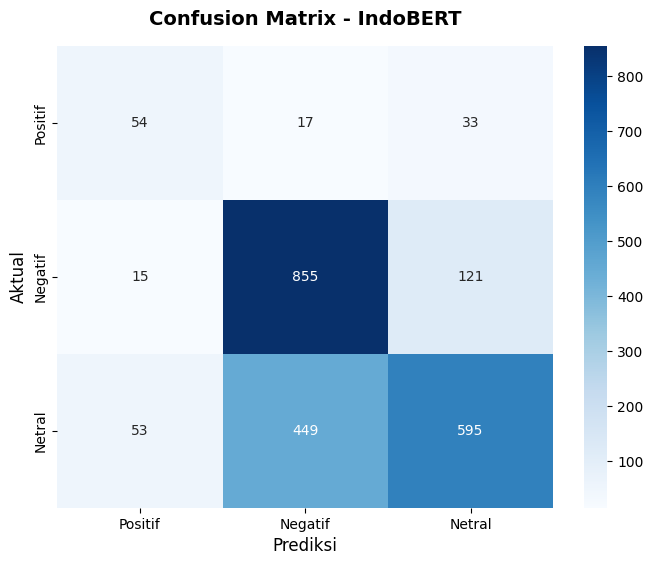

In [ ]:
# 3. Membuat Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Positif', 'Negatif', 'Netral'], yticklabels=['Positif', 'Negatif', 'Netral'])
plt.title('Confusion Matrix - IndoBERT', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.show()

# **8. Inference**

## 8.1 Preprocessing Function & Predictions

In [ ]:
import re
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

slang_dict = {
    "yg": "yang", "dgn": "dengan", "tdk": "tidak", "krn": "karena",
    "bgt": "banget", "kurmer": "kurikulum merdeka", "tp": "tapi",
    "tpi": "tapi", "th": "tahun", "ttg": "tentang", "dg": "dengan",
    "gak": "tidak", "ga": "tidak", "udh": "sudah", "sy": "saya",
    "jd": "jadi", "kalo": "kalau", "utk": "untuk", "dr": "dari",
    "pndidikan": "pendidikan", "ngajar": "mengajar", "trs": "terus",
    "sbg": "sebagai", "sj": "saja", "ngga": "tidak", "sdh": "sudah",
    "pd": "pada", "sprt": "seperti", "dlm": "dalam", "bs":"bisa",
    "ttp": "tetap", "bnyk": "banyak", "msh": "masih", "skrg": "sekarang",
    "gk": "tidak", "kpd": "kepada", "jg": "juga", "hrs": "harus",
    "dpt": "dapat", "lbh": "lebih", "kl": "kalau", "bljr": "belaajar",
    "blm": "belum", "bgus": "bagus", "ad": "ada", "kyk": "seperti",
    "brp": "berapa", "knp": "kenapa", "dri": "dari", "jga": "juga",
    "thn": "tahun", "g": "tidak", "tsb": "tersebut", "bkn": "bukan",
    "bgs": "bagus", "gurgem": "guru gembul", "trus": "terus",
    "kurmer": "kurikulum merdeka", "kumer": "kurikulum merdeka",
    "kepsek": "kepala sekolah", "pmm": "platform merdeka mengajar",
    "kalo": "kalau", "klo": "kalau", "gk": "tidak", "tp": "tapi",
    "gmn": "bagaimana", "ribet": "rumit", "org": "orang", "jgn": "jangan",
    "gt": "gitu", "kt": "kata", "aj": "aja", "gw": "saya"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^\w\s]', ' ', text)
    text = text.replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_slang(text):
    words = text.split()
    normalized_words = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized_words)

def preprocess_inference(text):
    return normalize_slang(clean_text(text))

model_path = './model_indobert_sentimen_kurmer_fixed'

tokenizer = AutoTokenizer.from_pretrained(model_path)
inference_model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inference_model.to(device)
inference_model.eval()

id2label = {
    0: 'Positif',
    1: 'Negatif',
    2: 'Netral'
}

def prediksi_sentimen(teks):
    teks_bersih = preprocess_inference(teks)

    inputs = tokenizer(
        teks_bersih,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = inference_model(**inputs)
        logits = outputs.logits
        probabilities = F.softmax(logits, dim=-1)

    pred_class = torch.argmax(probabilities, dim=-1).item()
    confidence = probabilities[0][pred_class].item() * 100
    pred_label = id2label[pred_class]

    print(f"Komentar asli   : {teks}")
    print(f"Komentar bersih : {teks_bersih}")
    print(f"Prediksi AI     : {pred_label}")
    print(f"Confidence      : {confidence:.2f}%")
    print(f"Probabilitas    : {probabilities.cpu().numpy()[0]}")
    print("-" * 70)

    return pred_label, confidence

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## 8.2 Contoh Prediksi Sentimen

In [ ]:
prediksi_sentimen("Menurut saya, kurikulum merdeka ini sangat membantu guru karena pembelajarannya jauh lebih fleksibel dan relevan dengan siswa.")

prediksi_sentimen("Beban administrasi PMM ini malah bikin guru tidak fokus mengajar siswa di kelas! Tolong kementerian dievaluasi lagi.")

prediksi_sentimen("Sekolah kami di daerah kabupaten akan mulai menerapkan modul kurikulum baru pada awal semester depan secara bertahap.")

prediksi_sentimen("Hebat sekali ya sistem sekarang, saking hebatnya sampai guru tidak sempat istirahat karena harus isi platform terus.")

prediksi_sentimen("Kurikulum paling buruk, membuat kesusahan.")

Komentar asli   : Menurut saya, kurikulum merdeka ini sangat membantu guru karena pembelajarannya jauh lebih fleksibel dan relevan dengan siswa.
Komentar bersih : menurut saya kurikulum merdeka ini sangat membantu guru karena pembelajarannya jauh lebih fleksibel dan relevan dengan siswa
Prediksi AI     : Positif
Confidence      : 96.38%
Probabilitas    : [0.96384335 0.01344129 0.02271544]
----------------------------------------------------------------------
Komentar asli   : Beban administrasi PMM ini malah bikin guru tidak fokus mengajar siswa di kelas! Tolong kementerian dievaluasi lagi.
Komentar bersih : beban administrasi platform merdeka mengajar ini malah bikin guru tidak fokus mengajar siswa di kelas tolong kementerian dievaluasi lagi
Prediksi AI     : Negatif
Confidence      : 89.24%
Probabilitas    : [0.00622001 0.89237577 0.10140423]
----------------------------------------------------------------------
Komentar asli   : Sekolah kami di daerah kabupaten akan mulai menerapkan

('Negatif', 85.86700558662415)

# **9. Ekspor Model**

## 9.1 Model HuggingFace

In [ ]:
save_path = "./deployment_model/indobert_sentimen"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Model HuggingFace saved at:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model HuggingFace saved at: ./deployment_model/indobert_sentimen


## 9.2 TorchScript
Untuk High Performance Backend / C++ / Low latency

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

# Ensure the model is on the correct device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = trainer.model # Get the trained model
model.to(device) # Move model to device
model.eval()

dummy_input = tokenizer(
    "contoh teks untuk export",
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128
)

# Move dummy_input tensors to the same device as the model
dummy_input = {k: v.to(device) for k, v in dummy_input.items()}

# Pass strict=False to handle dictionary outputs from the model
scripted_model = torch.jit.trace(model, (dummy_input["input_ids"], dummy_input["attention_mask"]), strict=False)

torchscript_path = "./deployment_model/indobert_sentimen_torchscript.pt"
torch.jit.save(scripted_model, torchscript_path)

print("TorchScript saved:", torchscript_path)

/usr/local/lib/python3.12/dist-packages/transformers/masking_utils.py:208: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if (padding_length := kv_length + kv_offset - attention_mask.shape[-1]) > 0:
/usr/local/lib/python3.12/dist-packages/transformers/integrations/sdpa_attention.py:77: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  is_causal = query.shape[2] > 1 and attention_mask is None and is_causal


TorchScript saved: ./deployment_model/indobert_sentimen_torchscript.pt


## 9.3 ONNX
Recommended untuk Deployment Modern

In [ ]:
!pip install onnxscript

from transformers import AutoModelForSequenceClassification
import torch

onnx_path = "./deployment_model/indobert_sentimen.onnx"

# Ensure the model is on the correct device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = trainer.model # Get the trained model
model.to(device) # Move model to device
model.eval()

dummy_input = tokenizer(
    "contoh teks untuk onnx export",
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128
)

# Move dummy_input tensors to the same device as the model
dummy_input = {k: v.to(device) for k, v in dummy_input.items()}

torch.onnx.export(
    model,
    (dummy_input["input_ids"], dummy_input["attention_mask"]),
    onnx_path,
    input_names=["input_ids", "attention_mask"],
    output_names=["logits"],
    dynamic_axes={
        "input_ids": {0: "batch_size"},
        "attention_mask": {0: "batch_size"},
        "logits": {0: "batch_size"}
    },
    opset_version=14
)

print("ONNX model saved:", onnx_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 20.1 MB/s eta 0:00:00


/tmp/ipykernel_1825/336986086.py:25: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0701 15:20:11.435000 1825 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `BertForSequenceClassification([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BertForSequenceClassification([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /project/onnx/version_converter/adapters/no_previous_version.h:24: adapt: Assertion `false` fa

[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...


[torch.onnx] Optimize the ONNX graph... ✅
ONNX model saved: ./deployment_model/indobert_sentimen.onnx


## 9.4 FastAPI


In [ ]:
# Menyimpan model
trainer.save_model("./deployment_api/model")
tokenizer.save_pretrained("./deployment_api/model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./deployment_api/model/tokenizer_config.json',
 './deployment_api/model/tokenizer.json')

In [ ]:
# FastAPI inference service
from fastapi import FastAPI
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

app = FastAPI()

model_path = "./deployment_api/model" # Corrected path to the saved model

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

label_map = {0: "Positif", 1: "Negatif", 2: "Netral"}

@app.post("/predict")
def predict(text: str):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return {
        "text": text,
        "label": label_map[pred],
        "confidence": float(probs[0][pred])
    }

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]